In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from sklearn.preprocessing import MinMaxScaler


2025-06-09 21:40:28.935445: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749494428.964782  395881 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749494428.972341  395881 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-09 21:40:29.014985: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Завантаження даних
data = pd.read_csv('./data/Electric_Production.csv')  # замініть на ваш файл з даними

data.head(10)

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151
5,6/1/1985,58.0904
6,7/1/1985,62.6202
7,8/1/1985,63.2485
8,9/1/1985,60.5846
9,10/1/1985,56.3154


In [3]:
values = data['IPG2211A2N'].values.reshape(-1, 1)

# Масштабування
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(values)

# Підготовка тренувальних даних
look_back = 10
X_train, y_train = [], []
for i in range(len(scaled_data) - look_back):
    X_train.append(scaled_data[i:i + look_back])
    y_train.append(scaled_data[i + look_back])

X_train, y_train = np.array(X_train), np.array(y_train)

In [4]:
model = Sequential()
model.add(SimpleRNN(units=50, activation='relu', input_shape=(look_back, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.15)


I0000 00:00:1749494433.292856  395881 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13687 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/dmitry/.local/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20


I0000 00:00:1749494435.271250  395994 service.cc:148] XLA service 0x7d27e00d57d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749494435.271337  395994 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3080 Ti Laptop GPU, Compute Capability 8.6
2025-06-09 21:40:35.292862: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749494435.380686  395994 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - loss: 0.0524 - mse: 0.0524

I0000 00:00:1749494435.653032  395994 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.0420 - mse: 0.0420 - val_loss: 0.0279 - val_mse: 0.0279
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0165 - mse: 0.0165 - val_loss: 0.0233 - val_mse: 0.0233
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0128 - mse: 0.0128 - val_loss: 0.0182 - val_mse: 0.0182
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0109 - mse: 0.0109 - val_loss: 0.0149 - val_mse: 0.0149
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0090 - mse: 0.0090 - val_loss: 0.0123 - val_mse: 0.0123
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0063 - mse: 0.0063 - val_loss: 0.0092 - val_mse: 0.0092
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0052 - mse: 0.0052 - val_loss: 0.0071 - val_mse: 0.0071
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0039 - mse: 0.0039 - val_loss: 0.0055 - val_mse: 0.0055
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0032 - mse: 0.0032 - v

In [5]:
def ShowTrainingHistory(history) :

    # Show training history
    h = history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['mse'], '.-',
                           epochs, h['val_mse'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Mse')
    plt.legend(['Train', 'Validation'])

    print('Train Acc     ', h['mse'][-1])
    print('Validation Acc', h['val_mse'][-1])   

Train Acc      0.0018581029726192355
Validation Acc 0.003308179322630167


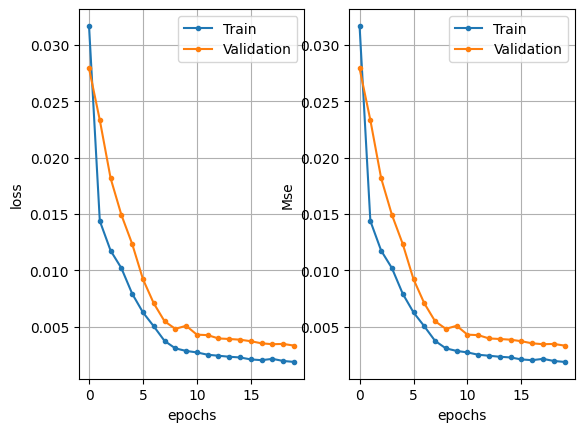

In [6]:
history = history.history
ShowTrainingHistory(history)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


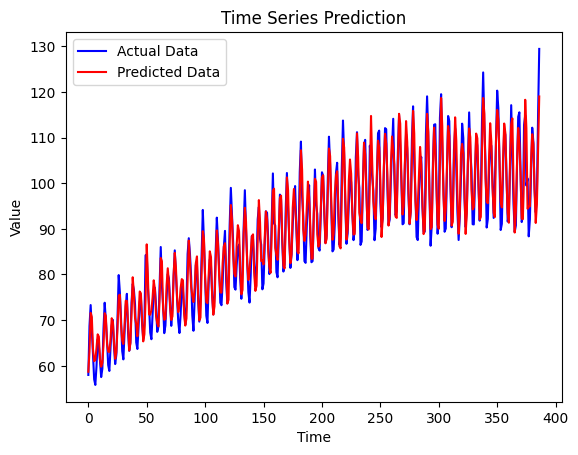

In [7]:
predictions = model.predict(X_train)
predictions = scaler.inverse_transform(predictions)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))

plt.plot(y_train_actual, color='blue', label='Actual Data')
plt.plot(predictions, color='red', label='Predicted Data')
plt.title('Time Series Prediction')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM


In [9]:
# Завантаження тексту
text = open('./data/text.txt', 'r', encoding='utf-8').read()

# Токенізація тексту
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1

# Створення послідовностей
input_sequences = []
for line in text.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

# Падінг послідовностей
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

# Поділ на вхідні та вихідні дані
X, y = input_sequences[:, :-1], input_sequences[:, -1]
y = tf.keras.utils.to_categorical(y, num_classes=total_words)


In [10]:
model = Sequential()
model.add(Embedding(total_words, 100, input_length=max_sequence_len-1))
model.add(LSTM(150, return_sequences=True))
model.add(LSTM(100))
model.add(Dense(total_words, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X, y, epochs=10, verbose=1, validation_split=0.15)


/home/dmitry/.local/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
978/978 ━━━━━━━━━━━━━━━━━━━━ 79s 79ms/step - accuracy: 0.0351 - loss: 8.2256 - val_accuracy: 0.0360 - val_loss: 7.9493
Epoch 2/10
978/978 ━━━━━━━━━━━━━━━━━━━━ 78s 80ms/step - accuracy: 0.0361 - loss: 7.4904 - val_accuracy: 0.0360 - val_loss: 8.1300
Epoch 3/10
978/978 ━━━━━━━━━━━━━━━━━━━━ 77s 79ms/step - accuracy: 0.0397 - loss: 7.3113 - val_accuracy: 0.0393 - val_loss: 8.3361
Epoch 4/10
978/978 ━━━━━━━━━━━━━━━━━━━━ 77s 78ms/step - accuracy: 0.0431 - loss: 7.1394 - val_accuracy: 0.0407 - val_loss: 8.4906
Epoch 5/10
978/978 ━━━━━━━━━━━━━━━━━━━━ 76s 78ms/step - accuracy: 0.0476 - loss: 6.9370 - val_accuracy: 0.0424 - val_loss: 8.7904
Epoch 6/10
978/978 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.0569 - loss: 6.6796 - val_accuracy: 0.0473 - val_loss: 8.9668
Epoch 7/10
978/978 ━━━━━━━━━━━━━━━━━━━━ 77s 79ms/step - accuracy: 0.0677 - loss: 6.4591 - val_accuracy: 0.0460 - val_loss: 9.1243
Epoch 8/10
978/978 ━━━━━━━━━━━━━━━━━━━━ 76s 78ms/step - accuracy: 0.0807 - loss: 6.2279 - 

In [11]:
def ShowTrainingHistory(history) :

    # Show training history
    h = history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])

    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])   

Train Acc      0.10684607177972794
Validation Acc 0.043643608689308167


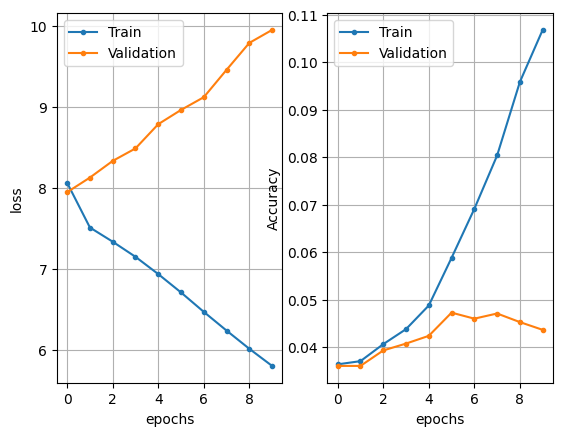

In [12]:
history = history.history
ShowTrainingHistory(history)

In [13]:
def generate_text(seed_text, next_words, model, max_sequence_len):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
        predicted = model.predict(token_list, verbose=0)
        predicted_word_index = np.argmax(predicted, axis=1)
        predicted_word = tokenizer.index_word[predicted_word_index[0]]
        seed_text += " " + predicted_word
    return seed_text

print(generate_text("Початковий текст", 50, model, max_sequence_len))


Початковий текст не не не не не не не не не не не не не не не не не не не не не не не не чем что то не мог я не хотел я не хотел я не хотел я не хотел я не хотел я не хотел я не хотел


In [14]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(look_back, 1)))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])

history_lstm = model_lstm.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.15)



Epoch 1/20


/home/dmitry/.local/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 423ms/step - loss: 0.1694 - mse: 0.1694 - val_loss: 0.2102 - val_mse: 0.2102
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0806 - mse: 0.0806 - val_loss: 0.0451 - val_mse: 0.0451
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0196 - mse: 0.0196 - val_loss: 0.0261 - val_mse: 0.0261
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0176 - mse: 0.0176 - val_loss: 0.0287 - val_mse: 0.0287
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0158 - mse: 0.0158 - val_loss: 0.0223 - val_mse: 0.0223
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0145 - mse: 0.0145 - val_loss: 0.0226 - val_mse: 0.0226
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0143 - mse: 0.0143 - val_loss: 0.0233 - val_mse: 0.0233
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0128 - mse: 0.0128 - val_loss: 0.0220 - val_mse: 0.0220
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0132 - mse: 0

In [16]:
from tensorflow.keras.layers import GRU

model_gru = Sequential()
model_gru.add(GRU(50, activation='relu', input_shape=(look_back, 1)))
model_gru.add(Dense(1))
model_gru.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])

history_gru = model_gru.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.15)


Epoch 1/20


/home/dmitry/.local/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.2692 - mse: 0.2692 - val_loss: 0.3812 - val_mse: 0.3812
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1681 - mse: 0.1681 - val_loss: 0.2388 - val_mse: 0.2388
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0884 - mse: 0.0884 - val_loss: 0.1046 - val_mse: 0.1046
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0289 - mse: 0.0289 - val_loss: 0.0248 - val_mse: 0.0248
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0217 - mse: 0.0217 - val_loss: 0.0284 - val_mse: 0.0284
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0169 - mse: 0.0169 - val_loss: 0.0310 - val_mse: 0.0310
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0166 - mse: 0.0166 - val_loss: 0.0232 - val_mse: 0.0232
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0149 - mse: 0.0149 - val_loss: 0.0231 - val_mse: 0.0231
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0148 - mse: 0